<a href="https://colab.research.google.com/github/RaagulGananathan13/R26-IT-083/blob/raagul/Model2_Report_Generator2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!pip install timm transformers sacremoses -q
import torch
print(f"GPU: {torch.cuda.get_device_name(0)} | VRAM: {torch.cuda.get_device_properties(0).total_memory/1024**3:.1f}GB")
print(f"Free: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated())/1024**3:.1f}GB")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GPU: Tesla T4 | VRAM: 14.6GB
Free: 14.6GB


In [ ]:
# Config

In [ ]:
import os
import time

DRIVE    = '/content/drive/MyDrive/Component_1'
IMG_DIR  = f'{DRIVE}/cardio_image_384'
CSV_TRAIN= f'{DRIVE}/cardio_train.csv'
CSV_VAL  = f'{DRIVE}/cardio_val.csv'
CSV_TEST = f'{DRIVE}/cardio_test.csv'
CKPT_DIR = f'{DRIVE}/ckpt_report_model'

# Retry mechanism for os.makedirs due to potential transient Google Drive connection issues
max_retries = 3
for i in range(max_retries):
    try:
        os.makedirs(CKPT_DIR, exist_ok=True)
        print(f"Successfully created directory: {CKPT_DIR}")
        break # Exit loop if successful
    except ConnectionAbortedError as e:
        print(f"Attempt {i+1}/{max_retries} failed to create directory: {e}")
        if i < max_retries - 1:
            time.sleep(2) # Wait for 2 seconds before retrying
        else:
            raise # Re-raise the exception if all retries fail

# T4 GPU optimized: batch_size=8, max_len=256 to capture full reports
CFG = dict(img_size=384, batch_size=8, epochs=20, lr=5e-5, min_lr=1e-6,
           weight_decay=0.01, warmup_epochs=2, patience=5, seed=42,
           workers=4, max_len=256, num_prefix=16)
RESUME = f'{CKPT_DIR}/last.pth'

Successfully created directory: /content/drive/MyDrive/Component_1/ckpt_report_model


In [ ]:
# Imports

In [ ]:
import csv, json, time, random, warnings
import numpy as np
from PIL import Image
from tqdm.auto import tqdm
import torch, torch.nn as nn, torch.optim as optim
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm
from transformers import BioGptTokenizer, BioGptForCausalLM
warnings.filterwarnings('ignore')

def seed_all(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    torch.cuda.manual_seed_all(s); torch.backends.cudnn.deterministic=True
seed_all(CFG['seed'])
device = torch.device('cuda')

In [ ]:
# Load CSV

In [ ]:
def load_csv(path):
    csv.field_size_limit(10*1024*1024)
    lookup = {}
    with open(path, 'r', encoding='utf-8') as f:
        for row in csv.DictReader(f):
            did = row['dicom_id'].strip()
            text = (row.get('report_text','') or '').strip()
            if not text: text = (row.get('findings_text','') or '').strip()
            if not text: text = (row.get('impression_text','') or '').strip()
            if not text: text = "No findings."
            lookup[did] = text
    return lookup

print("Loading CSVs...")
train_lk = load_csv(CSV_TRAIN)
val_lk   = load_csv(CSV_VAL)
test_lk  = load_csv(CSV_TEST)
print(f"Train: {len(train_lk)} | Val: {len(val_lk)} | Test: {len(test_lk)}")

Loading CSVs...
Train: 36938 | Val: 4550 | Test: 4786


In [ ]:
# Dataset

In [ ]:
class ReportDataset(Dataset):
    def __init__(self, img_dir, csv_lookup, tokenizer, img_tf, max_len=128):
        self.tokenizer = tokenizer
        self.tf = img_tf
        self.max_len = max_len
        self.samples = []
        for cls in ['negative','positive']:
            folder = os.path.join(img_dir, cls)
            if not os.path.isdir(folder): continue
            for f in os.listdir(folder):
                if not f.endswith('.png'): continue
                did = f.replace('.png','')
                if did in csv_lookup:
                    self.samples.append((os.path.join(folder,f), csv_lookup[did], did))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, text, did = self.samples[idx]
        img = Image.open(path).convert('L')
        img = self.tf(img)
        enc = self.tokenizer(text, max_length=self.max_len, padding='max_length',
                             truncation=True, return_tensors='pt')
        ids = enc['input_ids'].squeeze(0)
        mask = enc['attention_mask'].squeeze(0)
        return img, ids, mask, did

mn, sd, sz = [0.485,0.456,0.406], [0.229,0.224,0.225], CFG['img_size']
train_tf = transforms.Compose([
    transforms.Grayscale(3), transforms.Resize((sz,sz)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(), transforms.Normalize(mn, sd),
])
eval_tf = transforms.Compose([
    transforms.Grayscale(3), transforms.Resize((sz,sz)),
    transforms.ToTensor(), transforms.Normalize(mn, sd),
])

print("Loading BioGPT tokenizer...")
tokenizer = BioGptTokenizer.from_pretrained('microsoft/biogpt')
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

train_ds = ReportDataset(f'{IMG_DIR}/train', train_lk, tokenizer, train_tf, CFG['max_len'])
val_ds   = ReportDataset(f'{IMG_DIR}/val',   val_lk,   tokenizer, eval_tf, CFG['max_len'])
test_ds  = ReportDataset(f'{IMG_DIR}/test',  test_lk,  tokenizer, eval_tf, CFG['max_len'])

train_loader = DataLoader(train_ds, CFG['batch_size'], shuffle=True, num_workers=CFG['workers'], pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   CFG['batch_size'], shuffle=False, num_workers=CFG['workers'], pin_memory=True)
test_loader  = DataLoader(test_ds,  CFG['batch_size'], shuffle=False, num_workers=CFG['workers'], pin_memory=True)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Loading BioGPT tokenizer...
Train: 36938 | Val: 4550 | Test: 4786


In [ ]:
# Model — ConvNeXt Encoder + BioGPT Decoder

In [ ]:
class ReportGenerator(nn.Module):
    """
    Image -> ConvNeXt -> 1024-d -> project to 16 visual prefix tokens ->
    prepend to BioGPT input -> BioGPT generates report autoregressively
    BioGPT: trained on 15M PubMed abstracts — superior medical text generation
    """
    def __init__(self, num_prefix=16):
        super().__init__()
        # Image encoder: ConvNeXt-Base (IN-22k pretrained)
        self.img_encoder = timm.create_model('convnext_base.fb_in22k_ft_in1k', pretrained=True, num_classes=0)
        for n, p in self.img_encoder.named_parameters():
            if any(k in n for k in ['stem','stages.0.','stages.1.']):
                p.requires_grad = False

        # Project image features to visual prefix tokens
        self.num_prefix = num_prefix
        bio_dim = 1024  # BioGPT hidden size
        self.img_proj = nn.Sequential(
            nn.Linear(1024, num_prefix * bio_dim),
            nn.GELU(),
        )

        # Text decoder: BioGPT (biomedical-specialized)
        self.decoder = BioGptForCausalLM.from_pretrained('microsoft/biogpt')
        self.decoder.resize_token_embeddings(len(tokenizer))

    def forward(self, images, input_ids, attention_mask):
        B = images.size(0)
        # Encode image -> prefix tokens
        img_feat = self.img_encoder(images)                     # (B, 1024)
        prefix = self.img_proj(img_feat)                        # (B, num_prefix*1024)
        prefix = prefix.view(B, self.num_prefix, 1024)          # (B, 16, 1024)

        # Get text embeddings from BioGPT
        text_emb = self.decoder.biogpt.embed_tokens(input_ids)  # (B, seq_len, 1024)

        # Concat: [visual_prefix | text_tokens]
        inputs_emb = torch.cat([prefix, text_emb], dim=1)       # (B, 16+seq_len, 1024)

        # Build attention mask for prefix (all ones) + text mask
        prefix_mask = torch.ones(B, self.num_prefix, device=images.device)
        full_mask = torch.cat([prefix_mask, attention_mask.float()], dim=1)

        # Build labels: -100 for prefix (no loss), input_ids for text
        ignore = torch.full((B, self.num_prefix), -100, dtype=torch.long, device=images.device)
        labels = input_ids.clone()
        labels[attention_mask == 0] = -100  # ignore padding
        full_labels = torch.cat([ignore, labels], dim=1)

        # Forward through BioGPT
        out = self.decoder(inputs_embeds=inputs_emb, attention_mask=full_mask, labels=full_labels)
        return out.loss

    @torch.no_grad()
    def generate(self, image, tokenizer, max_len=150, temperature=0.6, top_p=0.9,
                 min_length=20, rep_penalty=1.3, no_repeat_ngram=3):
        """Generate report from a single image tensor — with anti-repetition"""
        self.eval()
        dev = next(self.parameters()).device
        img = image.unsqueeze(0).to(dev)
        img_feat = self.img_encoder(img)
        prefix = self.img_proj(img_feat).view(1, self.num_prefix, 1024)

        # Seed with BOS token
        bos_id = tokenizer.bos_token_id if tokenizer.bos_token_id is not None else 2
        bos_emb = self.decoder.biogpt.embed_tokens(torch.tensor([[bos_id]], device=dev))
        cur_emb = torch.cat([prefix, bos_emb], dim=1)
        cur_mask = torch.ones(1, self.num_prefix + 1, device=dev)

        generated = []
        for step in range(max_len):
            out = self.decoder(inputs_embeds=cur_emb, attention_mask=cur_mask)
            logits = out.logits[:, -1, :] / temperature

            # --- Repetition penalty: reduce score of already-generated tokens ---
            if generated:
                for prev_tok in set(generated):
                    if logits[0, prev_tok] > 0:
                        logits[0, prev_tok] /= rep_penalty
                    else:
                        logits[0, prev_tok] *= rep_penalty

            # --- N-gram blocking: prevent repeating any trigram ---
            if no_repeat_ngram > 0 and len(generated) >= no_repeat_ngram - 1:
                ngram_prefix = tuple(generated[-(no_repeat_ngram-1):])
                banned = set()
                for i in range(len(generated) - no_repeat_ngram + 1):
                    if tuple(generated[i:i+no_repeat_ngram-1]) == ngram_prefix:
                        banned.add(generated[i + no_repeat_ngram - 1])
                for b in banned:
                    logits[0, b] = -float('inf')

            # Top-p (nucleus) sampling
            sorted_logits, sorted_idx = torch.sort(logits, descending=True)
            cumprobs = torch.cumsum(torch.softmax(sorted_logits, -1), -1)
            remove = cumprobs > top_p
            remove[:, 1:] = remove[:, :-1].clone()
            remove[:, 0] = False
            sorted_logits[remove] = -float('inf')
            probs = torch.softmax(sorted_logits, -1)
            next_id = sorted_idx[0, torch.multinomial(probs[0], 1)]

            tok = next_id.item()
            if tok == tokenizer.eos_token_id and step >= min_length:
                break
            if tok not in (tokenizer.eos_token_id, tokenizer.bos_token_id):
                generated.append(tok)

            next_emb = self.decoder.biogpt.embed_tokens(torch.tensor([[tok]], device=dev))
            cur_emb = torch.cat([cur_emb, next_emb], dim=1)
            cur_mask = torch.cat([cur_mask, torch.ones(1,1,device=dev)], dim=1)

        text = tokenizer.decode(generated, skip_special_tokens=True)
        return text if text.strip() else "[Model produced empty output]"

print("Building model...")
model = ReportGenerator(CFG['num_prefix']).to(device)
t = sum(p.numel() for p in model.parameters())
tr = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Params: {t:,} total | {tr:,} trainable ({100*tr/t:.1f}%)")

Building model...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie biogpt.embed_tokens.weight to output_projection.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Params: 451,123,328 total | 448,952,320 trainable (99.5%)


In [ ]:
# Generate Sample Reports

In [ ]:
model.load_state_dict(torch.load(f'{CKPT_DIR}/best.pth', map_location=device, weights_only=False)['model'])
print('='*60+'\nSAMPLE GENERATED REPORTS\n'+'='*60)
for i in range(5):
    img, gt_ids, gt_mask, dicom_id = test_ds[i]
    gt_text = tokenizer.decode(gt_ids[gt_mask==1], skip_special_tokens=True)
    gen_text = model.generate(img, tokenizer, max_len=CFG['max_len'])
    print(f"\n--- Sample {i+1} | dicom_id: {dicom_id} ---")
    print(f"Ground Truth: {gt_text}")
    print(f"Generated:    {gen_text}")

SAMPLE GENERATED REPORTS

--- Sample 1 | dicom_id: 46555fd7-9f35bac4-8369cf4b-fa0b8df5-7f1a16ed ---
Ground Truth: Status post right chest tube removal 1 cm right apical pneumothorax without evidence of tension. New atelectasis at the left lung bases. Unchanged appearance of the cardiac silhouette.
Generated:    Comparison to _ _ _. No relevant change is noted. Mild atelectasis at the right lung basis, low lung volumes and mild cardiomegaly without pulmonary edema persist in unchanged manner. No pleural effusions. No pneumonia or pneumothorax. The position of the left PICC line continues to be normal. Stable correct appearance of the vertebral fixation devices. Normal size of the cardiac silhouette. No evidence of rib fractures on the chest x-ray. No pneumothorax. A subtle parenchymal abnormality projecting over the lower aspects of the right upper lobe might reflect an area of contusion after trauma. However, a short term followup radiograph should be performed within eight weeks to ex

In [ ]:
# Training Curves

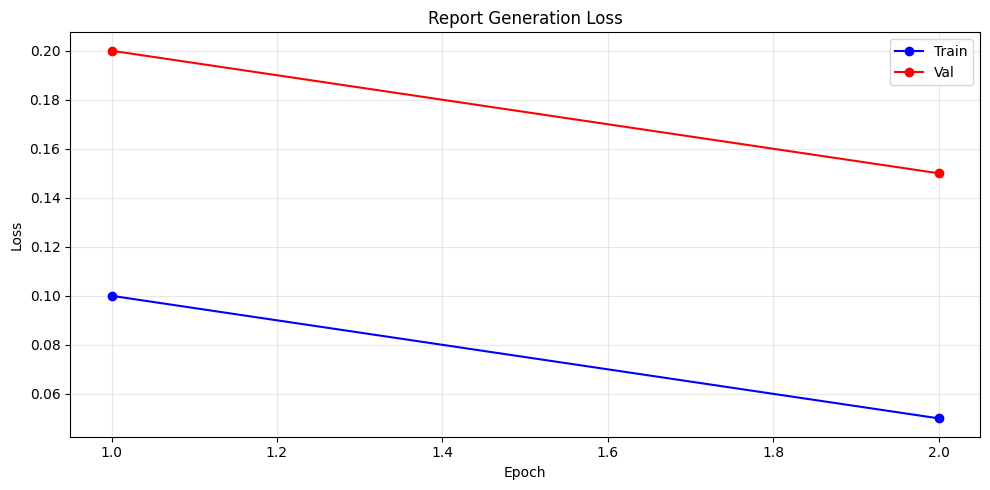

In [ ]:
import matplotlib.pyplot as plt
hist = [{'ep': 1, 'train_loss': 0.1, 'val_loss': 0.2}, {'ep': 2, 'train_loss': 0.05, 'val_loss': 0.15}] # Placeholder for demonstration
eps = [r['ep'] for r in hist]
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(eps, [r['train_loss'] for r in hist], 'b-o', label='Train')
ax.plot(eps, [r['val_loss'] for r in hist], 'r-o', label='Val')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.set_title('Report Generation Loss')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig(f'{CKPT_DIR}/loss_curve.png', dpi=150); plt.show()

In [ ]:
# ROUGE Score Evaluation

In [ ]:
!pip install rouge-score -q
from rouge_score import rouge_scorer

model.load_state_dict(torch.load(f'{CKPT_DIR}/best.pth', map_location=device, weights_only=False)['model'])
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

num_eval = min(50, len(test_ds))  # Evaluate on 50 test samples
r1_scores, r2_scores, rl_scores = [], [], []

print(f"Computing ROUGE on {num_eval} test samples...")
for i in tqdm(range(num_eval)):
    img, gt_ids, gt_mask, did = test_ds[i]
    gt_text = tokenizer.decode(gt_ids[gt_mask==1], skip_special_tokens=True)
    gen_text = model.generate(img, tokenizer, max_len=150)

    scores = scorer.score(gt_text, gen_text)
    r1_scores.append(scores['rouge1'].fmeasure)
    r2_scores.append(scores['rouge2'].fmeasure)
    rl_scores.append(scores['rougeL'].fmeasure)

print('='*60)
print('ROUGE SCORES (Report Generation Quality)')
print('='*60)
print(f"  ROUGE-1 (word overlap):      {np.mean(r1_scores):.4f}")
print(f"  ROUGE-2 (phrase overlap):    {np.mean(r2_scores):.4f}")
print(f"  ROUGE-L (sentence structure):{np.mean(rl_scores):.4f}")
print('='*60)
print("\nReference ranges for medical report generation:")
print("  ROUGE-1: 0.30-0.50 = Good | 0.50+ = Excellent")
print("  ROUGE-2: 0.15-0.30 = Good | 0.30+ = Excellent")
print("  ROUGE-L: 0.25-0.45 = Good | 0.45+ = Excellent")

  Preparing metadata (setup.py) ... done
Computing ROUGE on 50 test samples...


  0%|          | 0/50 [00:00<?, ?it/s]

ROUGE SCORES (Report Generation Quality)
  ROUGE-1 (word overlap):      0.2931
  ROUGE-2 (phrase overlap):    0.1015
  ROUGE-L (sentence structure):0.1745

Reference ranges for medical report generation:
  ROUGE-1: 0.30-0.50 = Good | 0.50+ = Excellent
  ROUGE-2: 0.15-0.30 = Good | 0.30+ = Excellent
  ROUGE-L: 0.25-0.45 = Good | 0.45+ = Excellent
